# **1-Dataset Checking and Cleaning**

In [1]:
import os
from pathlib import Path
from PIL import Image
import pandas as pd

In [2]:
BASE_DIR = Path.cwd()
DATASET_DIR_NAME = "Dataset"
DATASET_PATH = BASE_DIR / DATASET_DIR_NAME

dataset_override = os.environ.get("DATASET_PATH", "").strip()
if dataset_override:
    DATASET_PATH = Path(dataset_override)

if not DATASET_PATH.exists():
    candidates = []
    for root in {BASE_DIR, BASE_DIR.parent}:
        for name in [DATASET_DIR_NAME, DATASET_DIR_NAME.lower(), "data", "dataset", "datasets"]:
            candidate = root / name
            if candidate.exists() and candidate.is_dir():
                candidates.append(candidate)

    if len(candidates) == 1:
        DATASET_PATH = candidates[0]

print("Base dir:", BASE_DIR)
print("Dataset path:", DATASET_PATH)
if not DATASET_PATH.exists():
    print("Dataset path not found. Set DATASET_PATH env var or update DATASET_DIR_NAME.")

Base dir: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning
Dataset path: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\Dataset


In [3]:
print("Exists:", DATASET_PATH.exists())
if DATASET_PATH.exists():
    body_part_folders = [p.name for p in DATASET_PATH.iterdir() if p.is_dir()]
    print("Body part folders:", body_part_folders)

Exists: True
Body part folders: ['Foot', 'Head', 'Torso', 'Udder']


**Scan folders and collect image information**

In [4]:
image_extensions = [".jpg", ".jpeg", ".png"]

records = []

for body_part_folder in DATASET_PATH.iterdir():
    if body_part_folder.is_dir():
        body_part = body_part_folder.name
        
        for class_folder in body_part_folder.iterdir():
            if class_folder.is_dir():
                class_name = class_folder.name
                
                for image_path in class_folder.iterdir():
                    if image_path.suffix.lower() in image_extensions:
                        records.append({
                            "image_path": str(image_path),
                            "body_part": body_part,
                            "class_name": class_name,
                            "file_name": image_path.name,
                            "extension": image_path.suffix.lower()
                        })

df = pd.DataFrame(records)

print("Total images found:", len(df))

summary = df.groupby(["body_part", "class_name"]).size().reset_index(name="count")
summary

Total images found: 2644


,body_part,class_name,count
0,Foot,Diseased Foot,109
1,Foot,Normal Foot,52
2,Head,Diseased Head,388
3,Head,Normal Head,505
4,Torso,Diseased Torso,466
5,Torso,Normal Torso,445
6,Udder,Diseased Udder,358
7,Udder,Normal Udder,321


**Remove corrupted images from dataframe**

In [5]:
clean_df = df.copy()
clean_df = clean_df.sample(frac=1, random_state=42).reset_index(drop=True)

def check_images(df):
    bad_indices = []
    for idx, row in df.iterrows():
        path = row['image_path']
        try:
            with Image.open(path) as img:
                img.verify() # Verify file integrity
                # Some corruptions only show up when you actually load the data
                img = Image.open(path).convert("RGB")
                img.load() 
        except Exception as e:
            print(f"Corrupt image at index {idx}: {path} - Error: {e}")
            bad_indices.append(idx)
    return bad_indices

# Find them
bad_indices = check_images(clean_df)

# Remove them from your dataframe
if bad_indices:
    clean_df = clean_df.drop(bad_indices).reset_index(drop=True)
    print(f"Removed {len(bad_indices)} bad images.")

**Create labels for binary disease classification**

Normal = 0
Diseased = 1

In [6]:
def get_disease_label(class_name):
    class_name = class_name.lower()
    
    if "diseased" in class_name:
        return 1
    elif "normal" in class_name:
        return 0
    else:
        return None

clean_df["disease_label"] = clean_df["class_name"].apply(get_disease_label)
clean_df.head()

,image_path,body_part,class_name,file_name,extension,disease_label
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG_0500-02.jpg,.jpg,0
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,IMG-20220830-WA0200_jpg.rf.dc51fa35c90d25db5be...,.jpg,1
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,LSD-178-_png_jpg.rf.57f7674f88dee7c5a55bb2daa7...,.jpg,1
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG20230727071333.jpg,.jpg,0
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,sapi_q_2.jpg,.jpg,0


In [7]:
print("Missing disease labels:", clean_df["disease_label"].isna().sum())

Missing disease labels: 0


**Create body part labels for 4-class classifier**

In [8]:
body_part_to_label = {
    "head": 0,
    "foot": 1,
    "torso": 2,
    "udder": 3
}

label_to_body_part = {
    0: "Head",
    1: "Foot",
    2: "Torso",
    3: "Udder"
}

clean_df["body_part_label"] = clean_df["body_part"].str.lower().map(body_part_to_label)

missing_disease = clean_df["disease_label"].isna().sum()
missing_body = clean_df["body_part_label"].isna().sum()
if missing_disease or missing_body:
    print(
        f"Dropping rows with missing labels: "
        f"disease={missing_disease}, body_part={missing_body}"
    )
    clean_df = clean_df.dropna(
        subset=["disease_label", "body_part_label"]
    ).reset_index(drop=True)

clean_df.head()

,image_path,body_part,class_name,file_name,extension,disease_label,body_part_label
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG_0500-02.jpg,.jpg,0,0
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,IMG-20220830-WA0200_jpg.rf.dc51fa35c90d25db5be...,.jpg,1,2
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,LSD-178-_png_jpg.rf.57f7674f88dee7c5a55bb2daa7...,.jpg,1,2
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG20230727071333.jpg,.jpg,0,0
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,sapi_q_2.jpg,.jpg,0,0


In [9]:
print("Missing disease labels:", clean_df["disease_label"].isna().sum())
print("Missing body part labels:", clean_df["body_part_label"].isna().sum())

Missing disease labels: 0
Missing body part labels: 0


**Final dataset summary after cleaning**

In [10]:
final_summary = clean_df.groupby(["body_part", "class_name"]).size().reset_index(name="count")
final_summary

,body_part,class_name,count
0,Foot,Diseased Foot,109
1,Foot,Normal Foot,52
2,Head,Diseased Head,388
3,Head,Normal Head,505
4,Torso,Diseased Torso,466
5,Torso,Normal Torso,445
6,Udder,Diseased Udder,358
7,Udder,Normal Udder,321


In [11]:
clean_df.groupby("body_part").size().reset_index(name="total_images")

,body_part,total_images
0,Foot,161
1,Head,893
2,Torso,911
3,Udder,679


In [12]:
clean_df.groupby("disease_label").size().reset_index(name="count")

,disease_label,count
0,0,1323
1,1,1321


**Save clean metadata CSV**

In [13]:
OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

clean_metadata_path = OUTPUT_DIR / "clean_metadata.csv"
clean_df.to_csv(clean_metadata_path, index=False)

print("Saved clean metadata to:", clean_metadata_path)

Saved clean metadata to: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\clean_metadata.csv


# **2- Create Train / Validation / Test Splits**

In [14]:
import pandas as pd
from pathlib import Path
from sklearn.model_selection import train_test_split

**Load clean metadata**

In [15]:
OUTPUT_DIR = BASE_DIR / "outputs"

clean_metadata_path = OUTPUT_DIR / "clean_metadata.csv"

df = pd.read_csv(clean_metadata_path)

print("Total images:", len(df))
df.head()

Total images: 2644


,image_path,body_part,class_name,file_name,extension,disease_label,body_part_label
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG_0500-02.jpg,.jpg,0,0
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,IMG-20220830-WA0200_jpg.rf.dc51fa35c90d25db5be...,.jpg,1,2
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,LSD-178-_png_jpg.rf.57f7674f88dee7c5a55bb2daa7...,.jpg,1,2
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,IMG20230727071333.jpg,.jpg,0,0
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Head,Normal Head,sapi_q_2.jpg,.jpg,0,0


**Check labels**

In [16]:
print("Body part distribution:")
print(df["body_part"].value_counts())

print("\nDisease label distribution:")
print(df["disease_label"].value_counts())

Body part distribution:
body_part
Torso    911
Head     893
Udder    679
Foot     161
Name: count, dtype: int64

Disease label distribution:
disease_label
0    1323
1    1321
Name: count, dtype: int64


**Function to create stratified split**

70% train

15% validation

15% test

In [17]:
def create_train_val_test_split(dataframe, stratify_column, random_state=42):
    train_df, temp_df = train_test_split(
        dataframe,
        test_size=0.30,
        stratify=dataframe[stratify_column],
        random_state=random_state
    )
    
    val_df, test_df = train_test_split(
        temp_df,
        test_size=0.50,
        stratify=temp_df[stratify_column],
        random_state=random_state
    )
    
    train_df = train_df.copy()
    val_df = val_df.copy()
    test_df = test_df.copy()
    
    train_df["split"] = "train"
    val_df["split"] = "val"
    test_df["split"] = "test"
    
    final_df = pd.concat([train_df, val_df, test_df], axis=0)
    final_df = final_df.reset_index(drop=True)
    
    return final_df

**1- Create split for body part classifier**

For the body part classifier, we stratify by:

body_part_label

In [18]:
body_part_split_df = create_train_val_test_split(
    dataframe=df,
    stratify_column="body_part_label",
    random_state=42
)
body_part_split_df =body_part_split_df.sample(frac=1, random_state=42).reset_index(drop=True)
body_part_split_df.head()

,image_path,body_part,class_name,file_name,extension,disease_label,body_part_label,split
0,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Udder,Normal Udder,001_30_IMG_gro174291-009-848x565_jpg.rf.e944c7...,.jpg,0,3,train
1,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Normal Torso,HolsteinFriesiancattle107.jpg,.jpg,0,2,train
2,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Udder,Diseased Udder,NMC-TCP-chemical-damage1-e1515281879220-400x28...,.jpeg,1,3,train
3,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Normal Torso,BrownSwisscattle115.jpg,.jpg,0,2,train
4,c:\Users\ezzyo\OneDrive\Desktop\Machine_learni...,Torso,Diseased Torso,LSD-124-_png_jpg.rf.7ccb52a7f27860d17c31bb5396...,.jpg,1,2,train


In [19]:
body_part_split_summary = body_part_split_df.pivot_table(
    index="body_part",
    columns="split",
    values="image_path",
    aggfunc="count",
    fill_value=0
 )

body_part_split_summary["total"] = body_part_split_summary.sum(axis=1)
display(body_part_split_summary)

# --- New: counts broken down by class_name (Normal / Diseased) per split for each body_part
# This produces a table indexed by (body_part, class_name) with columns: train, val, test
class_counts = body_part_split_df.groupby(["body_part", "class_name", "split"]).size().unstack(fill_value=0)
# Show (body_part, class_name) rows with split columns
display(class_counts)
# Also present a wider table where class_name becomes columns (for easier reading)
class_counts_wide = class_counts.unstack(level=1).fillna(0).astype(int)
# `class_counts_wide` columns are a MultiIndex (split, class_name)
display(class_counts_wide)

split,test,train,val,total
body_part,,,,
Foot,24,113,24,161
Head,134,625,134,893
Torso,137,637,137,911
Udder,102,475,102,679


split                     test  train  val
body_part class_name                      
Foot      Diseased Foot     18     77   14
          Normal Foot        6     36   10
Head      Diseased Head     51    281   56
          Normal Head       83    344   78
Torso     Diseased Torso    69    327   70
          Normal Torso      68    310   67
Udder     Diseased Udder    52    251   55
          Normal Udder      50    224   47

split               test                                              \
class_name Diseased Foot Diseased Head Diseased Torso Diseased Udder   
body_part                                                              
Foot                  18             0              0              0   
Head                   0            51              0              0   
Torso                  0             0             69              0   
Udder                  0             0              0             52   

split                                                                train  \
class_name Normal Foot Normal Head Normal Torso Normal Udder Diseased Foot   
body_part                                                                    
Foot                 6           0            0            0            77   
Head                 0          83            0            0             0   
Torso                0           0           68            0             0   
Udder                0           0            0           50             0   

split                     ...                                     val  \
class_name Diseased Head  ... Normal Torso Normal Udder Diseased Foot   
body_part                 ...                                           
Foot                   0  ...            0            0            14   
Head                 281  ...            0            0             0   
Torso                  0  ...          310            0             0   
Udder                  0  ...            0          224             0   

split                                                               \
class_name Diseased Head Diseased Torso Diseased Udder Normal Foot   
body_part                                                            
Foot                   0              0              0          10   
Head                  56              0              0           0   
Torso                  0             70              0           0   
Udder                  0              0             55           0   

split                                             
class_name Normal Head Normal Torso Normal Udder  
body_part                                         
Foot                 0            0            0  
Head                78            0            0  
Torso                0           67            0  
Udder                0            0           47  

[4 rows x 24 columns]

**Save body part split**

In [20]:
SPLIT_DIR = BASE_DIR / "data_splits"
SPLIT_DIR.mkdir(parents=True, exist_ok=True)

body_part_split_path = SPLIT_DIR / "body_part_split.csv"

body_part_split_df.to_csv(body_part_split_path, index=False)

print("Saved:", body_part_split_path)

Saved: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\data_splits\body_part_split.csv


**2- Create binary split for one body part**

In [21]:
def create_binary_body_part_split(dataframe, body_part_name, random_state=42):
    body_df = dataframe[dataframe["body_part"] == body_part_name].copy()
    
    split_df = create_train_val_test_split(
        dataframe=body_df,
        stratify_column="disease_label",
        random_state=random_state
    )
    
    return split_df

In [22]:
head_split_df = create_binary_body_part_split(df, "Head")
foot_split_df = create_binary_body_part_split(df, "Foot")
torso_split_df = create_binary_body_part_split(df, "Torso")
udder_split_df = create_binary_body_part_split(df, "Udder")

In [23]:
def show_binary_split_summary(split_df, body_part_name):
    print(f"\n{body_part_name} split summary:")
    
    summary = split_df.pivot_table(
        index="class_name",
        columns="split",
        values="image_path",
        aggfunc="count",
        fill_value=0
    )
    
    summary["total"] = summary.sum(axis=1)
    display(summary)

In [24]:
show_binary_split_summary(head_split_df, "Head")
show_binary_split_summary(foot_split_df, "Foot")
show_binary_split_summary(torso_split_df, "Torso")
show_binary_split_summary(udder_split_df, "Udder")


Head split summary:


split,test,train,val,total
class_name,,,,
Diseased Head,58,272,58,388
Normal Head,76,353,76,505



Foot split summary:


split,test,train,val,total
class_name,,,,
Diseased Foot,17,76,16,109
Normal Foot,8,36,8,52



Torso split summary:


split,test,train,val,total
class_name,,,,
Diseased Torso,70,326,70,466
Normal Torso,67,311,67,445



Udder split summary:


split,test,train,val,total
class_name,,,,
Diseased Udder,54,250,54,358
Normal Udder,48,225,48,321


**Save all binary split CSV files**

In [25]:
head_split_df.to_csv(SPLIT_DIR / "head_split.csv", index=False)
foot_split_df.to_csv(SPLIT_DIR / "foot_split.csv", index=False)
torso_split_df.to_csv(SPLIT_DIR / "torso_split.csv", index=False)
udder_split_df.to_csv(SPLIT_DIR / "udder_split.csv", index=False)

print("All split files saved in:", SPLIT_DIR)

All split files saved in: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\data_splits


# **3- Build PyTorch Dataset and DataLoaders** 

In [26]:
import pandas as pd
from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

In [27]:
SPLIT_DIR = BASE_DIR / "data_splits"

body_part_split_path = SPLIT_DIR / "body_part_split.csv"
head_split_path = SPLIT_DIR / "head_split.csv"
foot_split_path = SPLIT_DIR / "foot_split.csv"
torso_split_path = SPLIT_DIR / "torso_split.csv"
udder_split_path = SPLIT_DIR / "udder_split.csv"

**Load split files**

In [28]:
body_part_df = pd.read_csv(body_part_split_path)

head_df = pd.read_csv(head_split_path)
foot_df = pd.read_csv(foot_split_path)
torso_df = pd.read_csv(torso_split_path)
udder_df = pd.read_csv(udder_split_path)

print("Body part images:", len(body_part_df))
print("Head images:", len(head_df))
print("Foot images:", len(foot_df))
print("Torso images:", len(torso_df))
print("Udder images:", len(udder_df))

Body part images: 2644
Head images: 893
Foot images: 161
Torso images: 911
Udder images: 679


**Define image transforms**

For training, we use augmentation.

For validation and test, we only resize and normalize.

In [29]:
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

foot_train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(25),
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [30]:
# Augmentation does not change dataset size. Set a factor to estimate "virtual" exposures.
augment_factor = 1  # Change to 5 or 10 if you want an estimated exposure count.

def show_counts_with_augmentation(split_df, name):
    print(f"\n{name} counts per split (original):")
    counts = split_df.groupby(["class_name", "split"]).size().unstack(fill_value=0)
    display(counts)
    if augment_factor > 1:
        print(f"\n{name} estimated exposures per epoch (x{augment_factor}):")
        display(counts * augment_factor)

show_counts_with_augmentation(body_part_df, "Body Part")

# For binary splits, uncomment the ones you want
show_counts_with_augmentation(head_df, "Head")
show_counts_with_augmentation(foot_df, "Foot")
show_counts_with_augmentation(torso_df, "Torso")
show_counts_with_augmentation(udder_df, "Udder")


Body Part counts per split (original):


split,test,train,val
class_name,,,
Diseased Foot,18,77,14
Diseased Head,51,281,56
Diseased Torso,69,327,70
Diseased Udder,52,251,55
Normal Foot,6,36,10
Normal Head,83,344,78
Normal Torso,68,310,67
Normal Udder,50,224,47



Head counts per split (original):


split,test,train,val
class_name,,,
Diseased Head,58,272,58
Normal Head,76,353,76



Foot counts per split (original):


split,test,train,val
class_name,,,
Diseased Foot,17,76,16
Normal Foot,8,36,8



Torso counts per split (original):


split,test,train,val
class_name,,,
Diseased Torso,70,326,70
Normal Torso,67,311,67



Udder counts per split (original):


split,test,train,val
class_name,,,
Diseased Udder,54,250,54
Normal Udder,48,225,48


**Class counts (augmentation does not change totals)**

In [31]:
def show_split_class_counts(dataframe, class_col, split_col="split"):
    summary = dataframe.pivot_table(
        index=class_col,
        columns=split_col,
        values="image_path",
        aggfunc="count",
        fill_value=0
    )
    summary["total"] = summary.sum(axis=1)
    display(summary)

print("Body-part class counts per split (unchanged by augmentation):")
show_split_class_counts(body_part_df, "body_part")

Body-part class counts per split (unchanged by augmentation):


split,test,train,val,total
body_part,,,,
Foot,24,113,24,161
Head,134,625,134,893
Torso,137,637,137,911
Udder,102,475,102,679


In [32]:
AUGMENT_DIR = OUTPUT_DIR / "augmented_images"
AUGMENT_SPLIT_DIR = OUTPUT_DIR / "augmented_splits"
AUGMENT_DIR.mkdir(parents=True, exist_ok=True)
AUGMENT_SPLIT_DIR.mkdir(parents=True, exist_ok=True)

augment_factor_save = 3
augment_save_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
        hue=0.02
    )
])

def save_augmented_images(split_df, name, augment_factor=3):
    train_df = split_df[split_df["split"] == "train"].copy()
    other_df = split_df[split_df["split"] != "train"].copy()
    
    aug_records = []
    for _, row in train_df.iterrows():
        image = Image.open(row["image_path"]).convert("RGB")
        body_part = str(row.get("body_part", "unknown"))
        class_name = str(row.get("class_name", "class"))
        out_dir = AUGMENT_DIR / body_part / class_name
        out_dir.mkdir(parents=True, exist_ok=True)
        base_name = Path(row["image_path"]).stem
        for n in range(augment_factor):
            aug_image = augment_save_transform(image)
            aug_path = out_dir / f"{base_name}_aug{n}.jpg"
            aug_image.save(aug_path)
            new_row = row.to_dict()
            new_row["image_path"] = str(aug_path)
            new_row["augmented"] = 1
            aug_records.append(new_row)
    
    train_df["augmented"] = 0
    other_df["augmented"] = 0
    aug_df = pd.DataFrame(aug_records)
    combined_df = pd.concat([train_df, aug_df, other_df], ignore_index=True)
    out_csv = AUGMENT_SPLIT_DIR / f"{name}_augmented.csv"
    combined_df.to_csv(out_csv, index=False)
    print(f"{name}: saved {len(aug_df)} augmented images -> {out_csv}")
    return combined_df

body_part_df_aug = save_augmented_images(body_part_df, "body_part", augment_factor_save)
head_df_aug = save_augmented_images(head_df, "head", augment_factor_save)
foot_df_aug = save_augmented_images(foot_df, "foot", augment_factor_save)
torso_df_aug = save_augmented_images(torso_df, "torso", augment_factor_save)
udder_df_aug = save_augmented_images(udder_df, "udder", augment_factor_save)

body_part: saved 5550 augmented images -> c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\augmented_splits\body_part_augmented.csv
head: saved 1875 augmented images -> c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\augmented_splits\head_augmented.csv
foot: saved 336 augmented images -> c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\augmented_splits\foot_augmented.csv
torso: saved 1911 augmented images -> c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\augmented_splits\torso_augmented.csv
udder: saved 1425 augmented images -> c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\augmented_splits\udder_augmented.csv


In [ ]:
# Ensure augmented splits are used downstream
if "body_part_df_aug" not in globals():
    body_part_df_aug = body_part_df
    head_df_aug = head_df
    foot_df_aug = foot_df
    torso_df_aug = torso_df
    udder_df_aug = udder_df

print("Using augmented splits for downstream steps.")
print("Body part rows:", len(body_part_df_aug))
print("Head rows:", len(head_df_aug))
print("Foot rows:", len(foot_df_aug))
print("Torso rows:", len(torso_df_aug))
print("Udder rows:", len(udder_df_aug))

**Save augmented images and use them in training**

**Create custom Dataset class**

This class can work for both:

- body part classifier
- binary disease classifier

In [33]:
class CattleImageDataset(Dataset):
    def __init__(
        self,
        dataframe,
        target_column,
        transform=None,
        body_part_transforms=None,
        body_part_column="body_part"
    ):
        self.dataframe = dataframe.reset_index(drop=True)
        self.target_column = target_column
        self.transform = transform
        self.body_part_transforms = body_part_transforms or {}
        self.body_part_column = body_part_column
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]
        
        image_path = row["image_path"]
        label = int(row[self.target_column])
        
        image = Image.open(image_path).convert("RGB")
        
        transform = self.transform
        if self.body_part_column in row and self.body_part_transforms:
            body_part = str(row[self.body_part_column])
            transform = self.body_part_transforms.get(body_part, transform)
        
        if transform:
            image = transform(image)
        
        return image, label

**Function to create DataLoaders**

In [34]:
def get_num_workers():
    return 0 if os.name == "nt" else 2


def create_dataloaders(
    split_df,
    target_column,
    batch_size=32,
    train_transform_override=None,
    body_part_transforms=None
 ):
    train_df = split_df[split_df["split"] == "train"].copy()
    val_df = split_df[split_df["split"] == "val"].copy()
    test_df = split_df[split_df["split"] == "test"].copy()
    
    train_transform_to_use = train_transform_override or train_transform
    
    train_dataset = CattleImageDataset(
        dataframe=train_df,
        target_column=target_column,
        transform=train_transform_to_use,
        body_part_transforms=body_part_transforms
    )
    
    val_dataset = CattleImageDataset(
        dataframe=val_df,
        target_column=target_column,
        transform=eval_transform
    )
    
    test_dataset = CattleImageDataset(
        dataframe=test_df,
        target_column=target_column,
        transform=eval_transform
    )
    
    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=get_num_workers(),
        pin_memory=torch.cuda.is_available()
    )
    
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=get_num_workers(),
        pin_memory=torch.cuda.is_available()
    )
    
    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=get_num_workers(),
        pin_memory=torch.cuda.is_available()
    )
    
    return train_loader, val_loader, test_loader

**1- Create DataLoaders for body part classifier**

**Target column:**  body_part_label

In [35]:
body_train_loader, body_val_loader, body_test_loader = create_dataloaders(
    split_df=body_part_df_aug,
    target_column="body_part_label",
    batch_size=32
)

print("Body part DataLoaders created.")

Body part DataLoaders created.


**2- Create DataLoaders for binary disease models**

**Target column:** disease_label

**For Foot, We used:**

batch_size=16

because the dataset is small.

In [36]:
head_train_loader, head_val_loader, head_test_loader = create_dataloaders(
    split_df=head_df_aug,
    target_column="disease_label",
    batch_size=32
)

foot_train_loader, foot_val_loader, foot_test_loader = create_dataloaders(
    split_df=foot_df_aug,
    target_column="disease_label",
    batch_size=16
)

torso_train_loader, torso_val_loader, torso_test_loader = create_dataloaders(
    split_df=torso_df_aug,
    target_column="disease_label",
    batch_size=32
)

udder_train_loader, udder_val_loader, udder_test_loader = create_dataloaders(
    split_df=udder_df_aug,
    target_column="disease_label",
    batch_size=32
)

print("Binary disease DataLoaders created.")

Binary disease DataLoaders created.


**Check one batch**

In [37]:
images, labels = next(iter(body_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([0, 3, 0, 0, 3, 3, 3, 2, 3, 2])


**Check binary batch**

In [38]:
images, labels = next(iter(head_train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels[:10])

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Labels: tensor([1, 0, 0, 0, 0, 1, 0, 0, 1, 0])


**Show class mappings**

In [39]:
body_part_labels = {
    0: "Head",
    1: "Foot",
    2: "Torso",
    3: "Udder"
}

disease_labels = {
    0: "Normal",
    1: "Diseased"
}

print("Body part labels:", body_part_labels)
print("Disease labels:", disease_labels)

Body part labels: {0: 'Head', 1: 'Foot', 2: 'Torso', 3: 'Udder'}
Disease labels: {0: 'Normal', 1: 'Diseased'}


**Save label mappings**

In [40]:
import json

OUTPUT_DIR = BASE_DIR / "outputs"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

labels = {
    "body_part_labels": {
        "0": "Head",
        "1": "Foot",
        "2": "Torso",
        "3": "Udder"
    },
    "disease_labels": {
        "0": "Normal",
        "1": "Diseased"
    }
}

labels_path = OUTPUT_DIR / "labels.json"

with open(labels_path, "w") as f:
    json.dump(labels, f, indent=4)

print("Saved labels to:", labels_path)

Saved labels to: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\outputs\labels.json


**Final Check**

In [41]:
def check_loader(loader, name):
    images, labels = next(iter(loader))
    print(f"{name}")
    print("Images:", images.shape)
    print("Labels:", labels.shape)
    print()

check_loader(body_train_loader, "Body Part Train Loader")
check_loader(head_train_loader, "Head Train Loader")
check_loader(foot_train_loader, "Foot Train Loader")
check_loader(torso_train_loader, "Torso Train Loader")
check_loader(udder_train_loader, "Udder Train Loader")

Body Part Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])

Head Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])

Foot Train Loader
Images: torch.Size([16, 3, 224, 224])
Labels: torch.Size([16])

Torso Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])

Udder Train Loader
Images: torch.Size([32, 3, 224, 224])
Labels: torch.Size([32])



# **4- Transfer Learning (ResNet18)**

In [42]:
import copy
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import models
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import numpy as np
from pathlib import Path

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

Using device: cpu


**Define ResNet18 model**

In [44]:
resnet_weights = models.ResNet18_Weights.DEFAULT
resnet_model = models.resnet18(weights=resnet_weights)

for param in resnet_model.parameters():
    param.requires_grad = False

num_features = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_features, 4)
resnet_model = resnet_model.to(device)

trainable_params = sum(
    param.numel() for param in resnet_model.parameters() if param.requires_grad
 )
print("Trainable params:", trainable_params)

Trainable params: 2052


**Define loss function and optimizer**

In [45]:
resnet_criterion = nn.CrossEntropyLoss()

resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=1e-3
)

**Training function for one epoch**

In [46]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        
        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc

**Evaluation function**

In [47]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    
    running_loss = 0.0
    correct = 0
    total = 0
    
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            
            _, predicted = torch.max(outputs, 1)
            
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
            
            all_labels.extend(labels.cpu().numpy())
            all_predictions.extend(predicted.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    
    return epoch_loss, epoch_acc, all_labels, all_predictions

**Full training loop**

In [48]:
def train_model(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=10):
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": []
    }
    
    best_val_acc = 0.0
    best_model_state = copy.deepcopy(model.state_dict())
    
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 30)
        
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        val_loss, val_acc, _, _ = evaluate_model(
            model, val_loader, criterion, device
        )
        
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
        print()
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = copy.deepcopy(model.state_dict())
    
    model.load_state_dict(best_model_state)
    
    print("Best validation accuracy:", best_val_acc)
    
    return model, history

**Train ResNet18 on body part classification**

In [49]:
resnet_model, resnet_history = train_model(
    model=resnet_model,
    train_loader=body_train_loader,
    val_loader=body_val_loader,
    criterion=resnet_criterion,
    optimizer=resnet_optimizer,
    device=device,
    num_epochs=10
)

Epoch 1/10
------------------------------
Train Loss: 0.8297 | Train Acc: 0.6631
Val Loss:   0.5097 | Val Acc:   0.8086

Epoch 2/10
------------------------------
Train Loss: 0.6235 | Train Acc: 0.7666
Val Loss:   0.3845 | Val Acc:   0.8539

Epoch 3/10
------------------------------
Train Loss: 0.5907 | Train Acc: 0.7745
Val Loss:   0.3573 | Val Acc:   0.8690

Epoch 4/10
------------------------------
Train Loss: 0.5686 | Train Acc: 0.7796
Val Loss:   0.3281 | Val Acc:   0.8715

Epoch 5/10
------------------------------
Train Loss: 0.5750 | Train Acc: 0.7823
Val Loss:   0.3421 | Val Acc:   0.8841

Epoch 6/10
------------------------------
Train Loss: 0.5408 | Train Acc: 0.7893
Val Loss:   0.3171 | Val Acc:   0.8690

Epoch 7/10
------------------------------
Train Loss: 0.5348 | Train Acc: 0.7961
Val Loss:   0.3122 | Val Acc:   0.8766

Epoch 8/10
------------------------------
Train Loss: 0.5489 | Train Acc: 0.7876
Val Loss:   0.3028 | Val Acc:   0.8791

Epoch 9/10
---------------------

**Plot training curves**

In [50]:
def plot_training_history(history, title):
    epochs = range(1, len(history["train_loss"]) + 1)
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title + " - Loss")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title + " - Accuracy")
    plt.legend()
    plt.show()

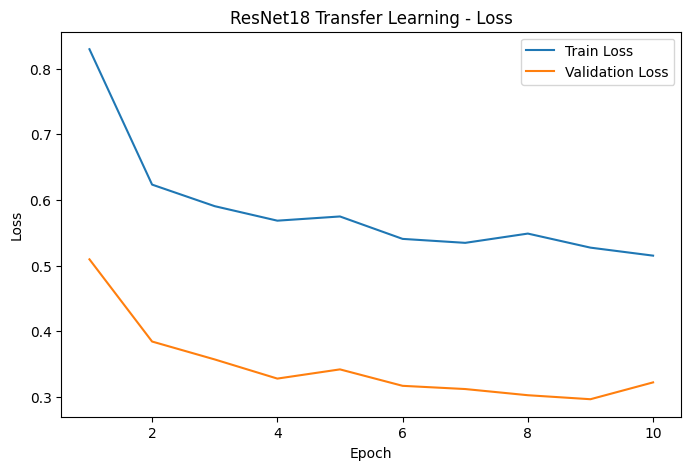

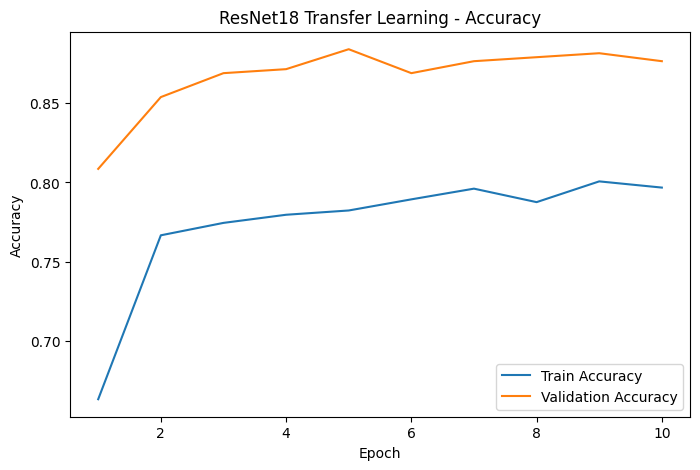

In [51]:
plot_training_history(resnet_history, "ResNet18 Transfer Learning")

**Evaluate on test set**

In [52]:
resnet_test_loss, resnet_test_acc, resnet_y_true, resnet_y_pred = evaluate_model(
    model=resnet_model,
    data_loader=body_test_loader,
    criterion=resnet_criterion,
    device=device
)

print("ResNet18 Test Loss:", resnet_test_loss)
print("ResNet18 Test Accuracy:", resnet_test_acc)

ResNet18 Test Loss: 0.3517941430548877
ResNet18 Test Accuracy: 0.8664987405541562


In [53]:
body_part_class_names = ["Head", "Foot", "Torso", "Udder"]

print(classification_report(
    resnet_y_true,
    resnet_y_pred,
    target_names=body_part_class_names
) )

              precision    recall  f1-score   support

        Head       0.92      0.82      0.87       134
        Foot       0.75      0.75      0.75        24
       Torso       0.82      0.95      0.88       137
       Udder       0.91      0.84      0.87       102

    accuracy                           0.87       397
   macro avg       0.85      0.84      0.84       397
weighted avg       0.87      0.87      0.87       397



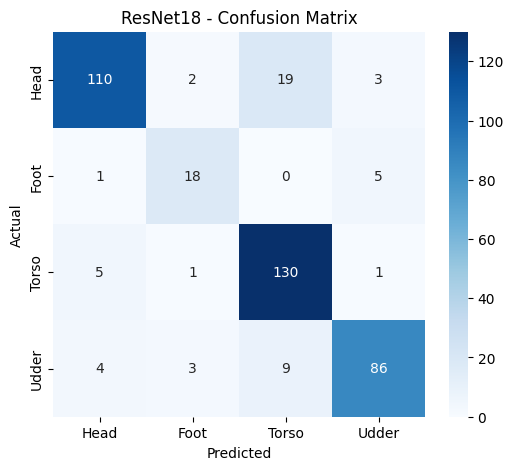

In [54]:
resnet_cm = confusion_matrix(resnet_y_true, resnet_y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    resnet_cm,
    annot=True,
    fmt="d",
    xticklabels=body_part_class_names,
    yticklabels=body_part_class_names,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("ResNet18 - Confusion Matrix")
plt.show()

**Save ResNet18 model**

In [55]:
MODEL_DIR = BASE_DIR / "saved_models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

resnet_model_path = MODEL_DIR / "resnet18_body_part.pth"

torch.save(resnet_model.state_dict(), resnet_model_path)

print("Saved ResNet18 model to:", resnet_model_path)

Saved ResNet18 model to: c:\Users\ezzyo\OneDrive\Desktop\Machine_learning\saved_models\resnet18_body_part.pth
